In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operation1: str
    operation2: str
    finalNumber1: int
    finalNumber2: int


In [3]:
def adder1(state: AgentState) -> AgentState:
    """1st add node"""
    state['finalNumber1'] = state['number1'] + state['number2']
    return state

def subtractor1(state: AgentState) -> AgentState:
    """1st subtract node"""
    state['finalNumber1'] = state['number1'] - state['number2']
    return state

def decide_next_node1(state: AgentState) -> AgentState:
    """1st deciding node"""
    if state['operation1'] == '+':
        return 'addition_operation1'
    elif state['operation1'] == '-':
        return 'subtractor_operation1'
    
def adder2(state: AgentState) -> AgentState:
    """2nd add node"""
    state['finalNumber2'] = state['number3'] + state['number4']
    return state

def subtractor2(state: AgentState) -> AgentState:
    """2nd subtract node"""
    state['finalNumber2'] = state['number3'] - state['number4']
    return state

def decide_next_node2(state: AgentState) -> AgentState:
    """2nd deciding node"""
    if state['operation2'] == '+':
        return 'addition_operation2'
    elif state['operation2'] == '-':
        return 'subtractor_operation2'

In [4]:
graph = StateGraph(AgentState)

graph.add_node('add_node1', adder1)
graph.add_node('subtract_node1', subtractor1)
graph.add_node('router1', lambda state:state)

graph.add_node('add_node2', adder2)
graph.add_node('subtract_node2', subtractor2)
graph.add_node('router2', lambda state:state)

graph.add_edge(START, 'router1')

graph.add_conditional_edges(
    'router1',
    decide_next_node1,
    {
        'addition_operation1': 'add_node1',
        'subtractor_operation1': 'subtract_node1'
    }
)

graph.add_edge('add_node1', 'router2')
graph.add_edge('subtract_node1', 'router2')

graph.add_conditional_edges(
    'router2',
    decide_next_node2,
    {
        'addition_operation2': 'add_node2',
        'subtractor_operation2': 'subtract_node2'
    }
)

graph.add_edge('add_node2', END)
graph.add_edge('subtract_node2', END)

app = graph.compile()

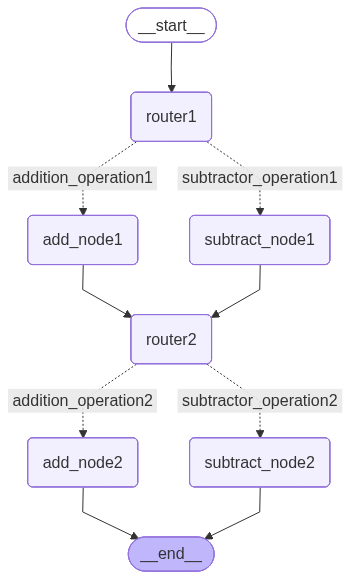

In [5]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
initial_state = AgentState(number1 = 10, operation1="-", number2 = 5, number3 = 7, number4=2, operation2="+", finalNumber1= 0, finalNumber2 = 0)
print(app.invoke(initial_state))

{'number1': 10, 'number2': 5, 'number3': 7, 'number4': 2, 'operation1': '-', 'operation2': '+', 'finalNumber1': 5, 'finalNumber2': 9}
